In [2]:
# Importo Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display, Math

# Ejercicio 1
Dadas las siguientes funciones de oferta y demanda:

$ Qd=\sqrt{16-p}$

$ Qs=p/2-1/2$  

Calcular EC y EP
Graficar ambas funciones en un mismo gráfico, donde el eje vertical debe ser el precio y el horizontal la cantidad.
Sombrear las áreas correspondientes a los excedentes encontrados indicando en el gráfico cuál es el excedente del consumidor y cuál el del productor


* Recalcular los excedentes teniendo en cuenta que se implementa un impuesto de suma fija $t=3$ a los productores. Interpretar.


## Parte a

### Paso 1: Planteo y validación del problema

In [3]:
# 1.1 Defino variables simbólicas
p, q = sp.symbols('p q', positive=True, real=True)

In [4]:
# 1.2 Defino funciones de demanda y oferta
Q_d = sp.sqrt(16 - p)  # Demanda: qd = √(16-p)
Q_s = p/2 - sp.Rational(1, 2)  # Oferta: qs = p/2 - 1/2
print('Funciones definidas.')
display(Math(f'Q_d = {sp.latex(Q_d)}'))
display(Math(f'Q_s = {sp.latex(Q_s)}'))

Funciones definidas.


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
# 1.3 Encuentro funciones inversas P_d(q) y P_s(q)
P_d = sp.solve(sp.Eq(q, Q_d), p)[0]
P_s = sp.solve(sp.Eq(q, Q_s), p)[0]
print('Funciones inversas encontradas.')
display(Math(f'P_d(q) = {sp.latex(P_d)}'))
display(Math(f'P_s(q) = {sp.latex(P_s)}'))

Funciones inversas encontradas.


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
# 1.4 Encuentro el punto de equilibrio P_d = P_s (q*, p*)
equilibrio = sp.Eq(P_d, P_s)
q_eq = sp.solve(equilibrio, q)[0]
p_eq = P_d.subs(q, q_eq)
print(f'Precio de equilibrio: p* = {p_eq:.2f}')
print(f'Cantidad de equilibrio: q* = {q_eq:.2f}')

Precio de equilibrio: p* = 7.00
Cantidad de equilibrio: q* = 3.00


In [ ]:
# Resumen Paso 1
print("✅ PASO 1 - PLANTEO Y VALIDACIÓN")
print("=" * 60)
print("FUNCIONES ORIGINALES (cantidad en función del precio):")
display(Math(f'Q_d = {sp.latex(Q_d)}'))
display(Math(f'Q_s = {sp.latex(Q_s)}'))
print()
print('FUNCIONES INVERSAS (precio en función de la cantidad):')
display(Math(f'P_d = {sp.latex(P_d)}'))
display(Math(f'P_s = {sp.latex(P_s)}'))
print()
print("EQUILIBRIO DEL MERCADO:")
print("Ecuación: P_d = P_s")
print(f'Precio de equilibrio: p* = {p_eq:.2f}')
print(f'Cantidad de equilibrio: q* = {q_eq:.2f}')
print()
print("INTERPRETACIÓN:")
print("• EC mide el área entre la curva de demanda y el precio de equilibrio")
print("• EP mide el área entre el precio de equilibrio y la curva de oferta")
print()
print("OBJETIVOS:")
display(Math(f"EC = \\int_0^{{{q_eq:.2f}}} [P_d(q) - {p_eq:.2f}]\\,dq"))
display(Math(f"EP = \\int_0^{{{q_eq:.2f}}} [{p_eq:.2f} - P_s(q)]\\,dq"))

✅ PASO 1 - PLANTEO Y VALIDACIÓN
FUNCIONES ORIGINALES (cantidad en función del precio):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


FUNCIONES INVERSAS (precio en función de la cantidad):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


EQUILIBRIO DEL MERCADO:
Ecuación: P_d = P_s
Precio de equilibrio: p* = 7.00
Cantidad de equilibrio: q* = 3.00

INTERPRETACIÓN:
• EC mide el área entre la curva de demanda y el precio de equilibrio
• EP mide el área entre el precio de equilibrio y la curva de oferta

OBJETIVOS:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Paso 2: Antiderivada y Barrow

In [8]:
# Excedente del consumidor (EC)
EC_integrando = P_d - p_eq
EC = sp.integrate(EC_integrando, (q, 0, q_eq))
EC

18

In [9]:
# Excedente del productor (EP)
EP_integrando = p_eq - P_s
EP = sp.integrate(EP_integrando, (q, 0, q_eq))
EP

9

In [10]:
# Excedente total (ET)
ET = EC + EP # type: ignore
ET

27

In [ ]:
# Resumen Paso 2
print("✅ PASO 2 - CÁLCULO DE EXCEDENTES")
print("=" * 60)
print("EXCEDENTE DEL CONSUMIDOR (EC):")
print(f"  Integrando: P_d(q) - p* = {sp.latex(EC_integrando)}")
print(f"  Resultado: EC = {float(EC):.2f}") # type: ignore
print()
print("EXCEDENTE DEL PRODUCTOR (EP):")
print(f"  Integrando: p* - P_s(q) = {sp.latex(EP_integrando)}")
print(f"  Resultado: EP = {float(EP):.2f}") # type: ignore
print()
print("EXCEDENTE TOTAL (ET):")
print(f"  ET = EC + EP = {float(ET):.2f}")

✅ PASO 2 - CÁLCULO DE EXCEDENTES
EXCEDENTE DEL CONSUMIDOR (EC):
  Integrando: P_d(q) - p* = 9 - q^{2}
  Resultado: EC = 18.00

EXCEDENTE DEL PRODUCTOR (EP):
  Integrando: p* - P_s(q) = 6 - 2 q
  Resultado: EP = 9.00

EXCEDENTE TOTAL (ET):
  ET = EC + EP = 27.00


### Paso 3: Visualización

In [12]:
# 3.1 Establezco dominio para graficar
q_grid = np.linspace(0, float(q_eq) * 1.5, 500)

In [13]:
# 3.2 Preparar datos para graficar
P_d_lambda = sp.lambdify(q, P_d, 'numpy')
P_s_lambda = sp.lambdify(q, P_s, 'numpy')

Pd_num = P_d_lambda(q_grid)
Ps_num = P_s_lambda(q_grid)

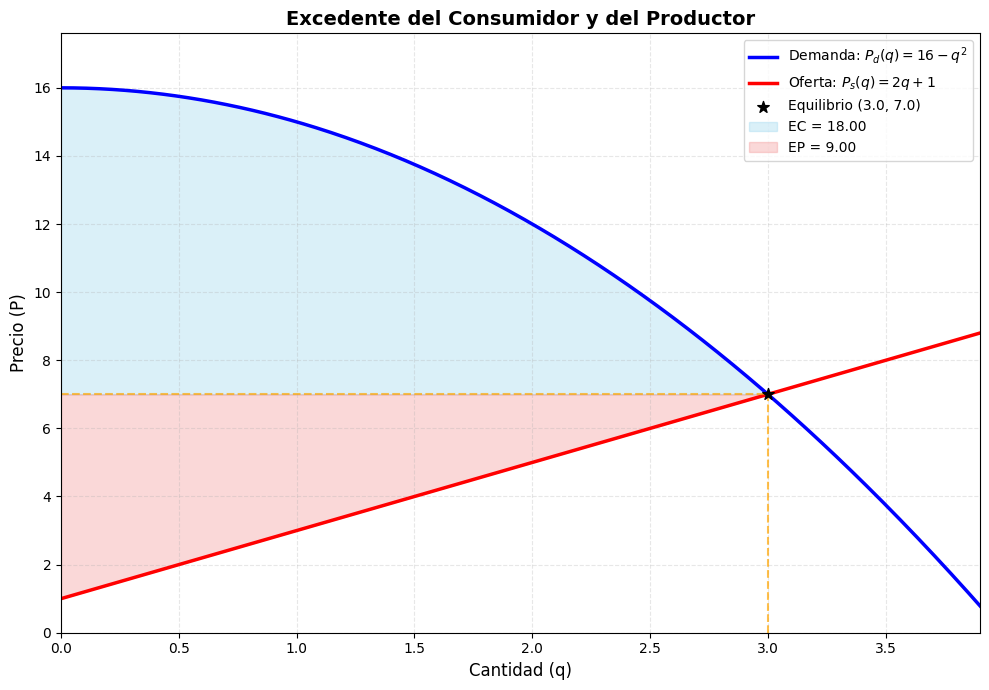

In [41]:
# Crear gráfico
plt.figure(figsize=(10, 7))
plt.plot(q_grid, Pd_num, label=f'Demanda: $P_d(q) = {sp.latex(P_d)}$', linewidth=2.5, color='blue')
plt.plot(q_grid, Ps_num, label=f'Oferta: $P_s(q) = {sp.latex(P_s)}$', linewidth=2.5, color='red')

# Punto de equilibrio
plt.scatter([q_eq], [p_eq], s=75, c='black', marker='*', zorder=5, label=f'Equilibrio ({q_eq:.1f}, {p_eq:.1f})')
plt.vlines(q_eq, 0, p_eq, linestyles='--', color='orange', alpha=0.7)
plt.hlines(p_eq, 0, q_eq, linestyles='--', color='orange', alpha=0.7)

# Sombrear excedentes
condicion = (q_grid <= float(q_eq)).tolist()
plt.fill_between(q_grid, Pd_num, float(p_eq), where=condicion, 
                 alpha=0.3, color='skyblue', label=f'EC = {float(EC):.2f}')
plt.fill_between(q_grid, float(p_eq), Ps_num, where=condicion, 
                 alpha=0.3, color='lightcoral', label=f'EP = {float(EP):.2f}')

plt.title('Excedente del Consumidor y del Productor', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12)
plt.ylabel('Precio (P)', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, float(q_eq) * 1.3)
plt.ylim(0, max(Pd_num) * 1.1)
plt.tight_layout()
plt.show()

### Paso 4: Interpretación económica

In [15]:
print("✅ PASO 4 - INTERPRETACIÓN ECONÓMICA")
print("=" * 60)
print(f"En equilibrio: q* = {float(q_eq):.2f} unidades, p* = ${float(p_eq):.2f}")
print()
print("EXCEDENTE DEL CONSUMIDOR (EC):")
print(f"  Valor: ${float(EC):.2f}")
print(f"  Representa el beneficio adicional que obtienen los consumidores")
print(f"  por pagar ${float(p_eq):.2f} en lugar de su disposición máxima a pagar.")
print(f"  Suma de: ∫[0,{float(q_eq):.1f}] [P_d(q) - {float(p_eq):.2f}] dq")
print()
print("EXCEDENTE DEL PRODUCTOR (EP):")
print(f"  Valor: ${float(EP):.2f}")
print(f"  Representa el beneficio adicional que obtienen los productores")
print(f"  por vender a ${float(p_eq):.2f} en lugar de su costo marginal.")
print(f"  Suma de: ∫[0,{float(q_eq):.1f}] [{float(p_eq):.2f} - P_s(q)] dq")
print()
print("EXCEDENTE TOTAL (ET):")
print(f"  Valor: ${float(ET):.2f}")
print(f"  Mide el bienestar social total generado por este mercado.")
print(f"  Un mercado competitivo maximiza este excedente.")

✅ PASO 4 - INTERPRETACIÓN ECONÓMICA
En equilibrio: q* = 3.00 unidades, p* = $7.00

EXCEDENTE DEL CONSUMIDOR (EC):
  Valor: $18.00
  Representa el beneficio adicional que obtienen los consumidores
  por pagar $7.00 en lugar de su disposición máxima a pagar.
  Suma de: ∫[0,3.0] [P_d(q) - 7.00] dq

EXCEDENTE DEL PRODUCTOR (EP):
  Valor: $9.00
  Representa el beneficio adicional que obtienen los productores
  por vender a $7.00 en lugar de su costo marginal.
  Suma de: ∫[0,3.0] [7.00 - P_s(q)] dq

EXCEDENTE TOTAL (ET):
  Valor: $27.00
  Mide el bienestar social total generado por este mercado.
  Un mercado competitivo maximiza este excedente.


## Paso b

Recalcular los excedentes teniendo en cuenta que se implementa un impuesto de suma fija $t=3$ a los productores. Interpretar. 

De esta manera, la oferta se traslada a $Qs=(p - t)/2-1/2$  


### Paso 1 Planteo y Validación del problema

In [16]:
# 1.1 Defino variables simbólicas
t = sp.symbols('t', positive=True, real=True)

In [17]:
# 1.2 Defino funciones de oferta con impuesto
Q_s_tax = ((p - t)/2) - sp.Rational(1, 2)  # Oferta con impuesto: qs = (p - t)/2 - 1/2
print('Funciones definidas.')
display(Math(r'Q_{s,tax} = ' + sp.latex(Q_s_tax)))

Funciones definidas.


<IPython.core.display.Math object>

In [18]:
# 1.3 Encuentro funciones inversas P_d(q) y P_s(q)
P_s_tax = sp.solve(sp.Eq(q, Q_s_tax), p)[0]
print('Función inversa de oferta con impuesto:')
display(Math(f'P_{{s_tax}}(q) = {sp.latex(P_s_tax)}'))

Función inversa de oferta con impuesto:


<IPython.core.display.Math object>

In [19]:
# 1.4 Agregamos t = 3
P_s_tax = P_s_tax.subs(t, 3)
display(Math(f'P_{{s_tax}}(q) = {sp.latex(P_s_tax)}'))

<IPython.core.display.Math object>

In [20]:
# 1.5 Encuentro el punto de equilibrio P_d = P_s (q*, p*)
equilibrio = sp.Eq(P_d, P_s_tax)
q_eq_tax = sp.solve(equilibrio, q)[0]
p_eq_tax = P_s_tax.subs(q, q_eq_tax)
print(f'Precio de equilibrio: p* = {p_eq_tax:.2f}')
print(f'Cantidad de equilibrio: q* = {q_eq_tax:.2f}')

Precio de equilibrio: p* = 9.21
Cantidad de equilibrio: q* = 2.61


In [21]:
# Resumen Paso 1
print("✅ PASO 1 - PLANTEO Y VALIDACIÓN")
print("=" * 60)
print("FUNCIONES ORIGINALES (cantidad en función del precio):")
display(Math(f'Q_d = {sp.latex(Q_d)}'))
display(Math(f'Q_{{s_tax}} = {sp.latex(Q_s_tax)}'))
print()
print('FUNCIONES INVERSAS (precio en función de la cantidad):')
display(Math(f'P_d = {sp.latex(P_d)}'))
display(Math(f'P_{{s_tax}} = {sp.latex(P_s_tax)}'))
print()
print("EQUILIBRIO DEL MERCADO:")
print("Ecuación: P_d = P_s")
print(f'Precio de equilibrio: p* = {p_eq_tax:.2f}')
print(f'Cantidad de equilibrio: q* = {q_eq_tax:.2f}')
print()
print("INTERPRETACIÓN:")
print("• EC mide el área entre la curva de demanda y el precio de equilibrio")
print("• EP mide el área entre el precio de equilibrio y la curva de oferta")
print()
print("OBJETIVOS:")
display(Math(f"EC = \\int_0^{{{q_eq_tax:.2f}}} [P_d(q) - {p_eq_tax:.2f}]\\,dq"))
display(Math(f"EP = \\int_0^{{{q_eq_tax:.2f}}} [{p_eq_tax:.2f} - P_s(q)]\\,dq"))

✅ PASO 1 - PLANTEO Y VALIDACIÓN
FUNCIONES ORIGINALES (cantidad en función del precio):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


FUNCIONES INVERSAS (precio en función de la cantidad):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


EQUILIBRIO DEL MERCADO:
Ecuación: P_d = P_s
Precio de equilibrio: p* = 9.21
Cantidad de equilibrio: q* = 2.61

INTERPRETACIÓN:
• EC mide el área entre la curva de demanda y el precio de equilibrio
• EP mide el área entre el precio de equilibrio y la curva de oferta

OBJETIVOS:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Paso 2: Antiderivada y Barrow

In [22]:
# Excedente del consumidor (EC)
EC_tax_integrando = P_d - p_eq_tax
EC_tax = sp.integrate(EC_tax_integrando, (q, 0, q_eq_tax))
EC_tax.evalf()

11.7925469382826

In [23]:
# Excedente del productor (EP)
EP_tax_integrando = p_eq_tax - P_s_tax
EP_tax = sp.integrate(EP_tax_integrando, (q, 0, q_eq_tax))
EP_tax.evalf()

6.78889744907202

In [24]:
# Excedente Total (ET)
ET_tax = EC_tax + EP_tax  # type: ignore
ET_tax.evalf()

18.5814443873546

In [25]:
# Resumen Paso 2
print("✅ PASO 2 - CÁLCULO DE EXCEDENTES")
print("=" * 60)
print("EXCEDENTE DEL CONSUMIDOR (EC_tax):")
print(f"  Integrando: P_d(q) - p* = {sp.latex(EC_tax_integrando)}")
print(f"  Resultado: EC = {float(EC_tax.evalf()):.2f}")
print()
print("EXCEDENTE DEL PRODUCTOR (EP_tax):")
print(f"  Integrando: p* - P_s(q) = {sp.latex(EP_tax_integrando)}")
print(f"  Resultado: EP = {float(EP_tax.evalf()):.2f}")
print()
print("EXCEDENTE TOTAL (ET_tax):")
print(f"  ET = EC + EP = {float(ET_tax.evalf()):.2f}")

✅ PASO 2 - CÁLCULO DE EXCEDENTES
EXCEDENTE DEL CONSUMIDOR (EC_tax):
  Integrando: P_d(q) - p* = - q^{2} - 2 \sqrt{13} + 14
  Resultado: EC = 11.79

EXCEDENTE DEL PRODUCTOR (EP_tax):
  Integrando: p* - P_s(q) = - 2 q - 2 + 2 \sqrt{13}
  Resultado: EP = 6.79

EXCEDENTE TOTAL (ET_tax):
  ET = EC + EP = 18.58


### Paso 3: Visualización

In [26]:
# 3.1 Establezco dominio para graficar
q_grid = np.linspace(0, float(q_eq) * 1.5, 500)

In [27]:
# 3.2 Preparar datos para graficar
Pd_num = sp.lambdify(q, P_d, 'numpy')(q_grid)
Ps_num = sp.lambdify(q, P_s, 'numpy')(q_grid)
Ps_t_num = sp.lambdify(q, P_s_tax, 'numpy')(q_grid)

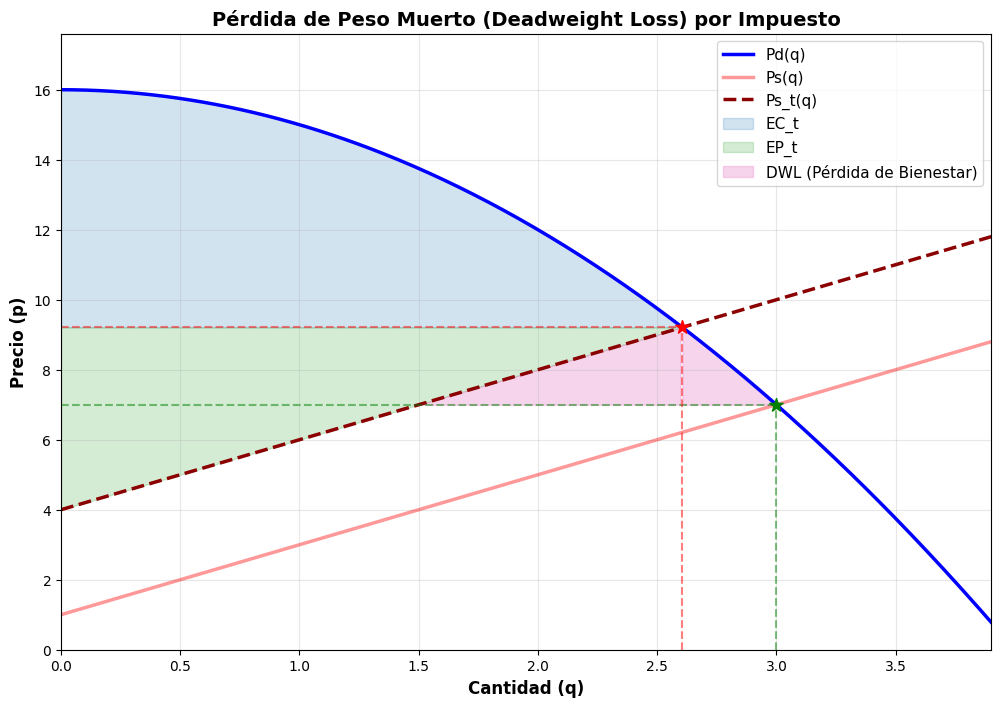

In [50]:
# 3.4 Gráfico de Pérdida de Peso Muerto (Deadweight Loss)
# Crear gráfico
plt.figure(figsize=(12, 8))
plt.plot(q_grid, Pd_num, label='Pd(q)', linewidth=2.5, color='blue')
plt.plot(q_grid, Ps_num, label='Ps(q)', linewidth=2.5, color='red', alpha=0.4)
plt.plot(q_grid, Ps_t_num, label='Ps_t(q)', linewidth=2.5, color='darkred', linestyle='--')

# Equilibrio original
plt.vlines(x=q_eq, ymin=0, ymax=p_eq, linestyles="--", color="green", alpha=0.5)
plt.hlines(y=p_eq, xmin=0, xmax=q_eq, linestyles="--", color="green", alpha=0.5)
plt.scatter([q_eq], [p_eq], c="green", s=100, zorder=5, marker="*")

# Equilibrio con impuesto
plt.vlines(x=q_eq_tax, ymin=0, ymax=p_eq_tax, linestyles="--", color="red", alpha=0.5)
plt.hlines(y=p_eq_tax, xmin=0, xmax=q_eq_tax, linestyles="--", color="red", alpha=0.5)
plt.scatter([q_eq_tax], [p_eq_tax], c="r", s=100, zorder=5, marker="*")

# Condición para áreas hasta el nuevo equilibrio
condicion_ec_t = (q_grid <= float(q_eq_tax))

# Excedente del Consumidor con impuesto
plt.fill_between(
    q_grid,
    Pd_num,
    float(p_eq_tax),
    where=condicion_ec_t, # type: ignore
    alpha=0.2,
    label='EC_t',
    color="tab:blue"
)

# Excedente del Productor con impuesto
plt.fill_between(
    q_grid,
    float(p_eq_tax),
    Ps_t_num,
    where=condicion_ec_t, # type: ignore
    alpha=0.2,
    label='EP_t',
    color="tab:green"
)

# Pérdida de Peso Muerto (DWL) - Parte Superior (derecha)
# Realizar operación booleana con arrays, LUEGO convertir a lista
condition_mask_superior = ((q_grid >= float(q_eq_tax)) & (q_grid <= float(q_eq))).tolist()

plt.fill_between(
    q_grid,
    float(p_eq),
    Pd_num,
    where=condition_mask_superior,
    alpha=0.3,
    label='DWL (Pérdida de Bienestar)',
    color="tab:pink"
)

# Pérdida de Peso Muerto (DWL) - Parte Inferior (izquierda)
# Usar el valor real calculado donde la oferta con impuesto cruza p_eq
condition_mask_inferior = ((q_grid >= float(Q_s_tax.subs({t: 3, p: p_eq}))) & (q_grid <= float(q_eq_tax))).tolist()

plt.fill_between(
    q_grid,
    float(p_eq),
    Ps_t_num,
    where=condition_mask_inferior,
    alpha=0.3,
    color="tab:pink"
)

plt.title('Pérdida de Peso Muerto (Deadweight Loss) por Impuesto', 
         fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12, fontweight='bold')
plt.ylabel('Precio (p)', fontsize=12, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.xlim(0, float(q_eq) * 1.3)
plt.ylim(0, max(Pd_num) * 1.1)
plt.show()

**MÉTODO 1: Cálculo del DWL usando la fórmula del área del triángulo**

In [29]:
# Triángulo izquierdo: Entre Ps_t y p_eq
q_base_izquierdo = Q_s_tax.subs({t: 3, p: p_eq})
base_izquierdo = q_eq_tax - q_base_izquierdo
altura = p_eq_tax - p_eq
area_triangulo_izquierdo = sp.Rational(1, 2) * base_izquierdo * altura

# Triángulo derecho: Entre Pd y p_eq
base_derecho = q_eq - q_eq_tax
area_triangulo_derecho = sp.Rational(1, 2) * base_derecho * altura

# DWL Total
DWL_triangulos = area_triangulo_izquierdo + area_triangulo_derecho

print("MÉTODO 1: FÓRMULA DEL TRIÁNGULO")
print("=" * 60)
print(f"Triángulo izquierdo: 1/2 × {float(base_izquierdo):.4f} × {float(altura):.4f} = {float(area_triangulo_izquierdo):.4f}")
print(f"Triángulo derecho:   1/2 × {float(base_derecho):.4f} × {float(altura):.4f} = {float(area_triangulo_derecho):.4f}")
print(f"\nDWL (triángulos) = {float(DWL_triangulos):.4f}")

MÉTODO 1: FÓRMULA DEL TRIÁNGULO
Triángulo izquierdo: 1/2 × 1.1056 × 2.2111 = 1.2222
Triángulo derecho:   1/2 × 0.3944 × 2.2111 = 0.4361

DWL (triángulos) = 1.6583


**MÉTODO 2: Cálculo del DWL usando integrales definidas**

$$ DWL = \int\limits_{Q_{s\_tax}(p_{eq})}^{q_{eq\_tax}} [P_{s\_tax}(q) - p_{eq}] \ dq + \int\limits_{q_{eq\_tax}}^{q_{eq}} [P_{d}(q) - p_{eq}] \ dq $$

In [ ]:
# Integral 1 (triángulo izquierdo): Entre Ps_t y p_eq
DWL_int_izquierdo = sp.integrate(
    P_s_tax - p_eq,
    (q, Q_s_tax.subs({t: 3, p: p_eq}), q_eq_tax)
)

# Integral 2 (triángulo derecho): Entre Pd y p_eq
DWL_int_derecho = sp.integrate(
    P_d - p_eq,
    (q, q_eq_tax, q_eq)
)

# DWL Total con integrales
DWL_integrales = DWL_int_izquierdo + DWL_int_derecho # type: ignore

print("MÉTODO 2: INTEGRALES DEFINIDAS")
print("=" * 60)
print(f"Integral izquierda:  ∫[{float(Q_s_tax.subs({t: 3, p: p_eq})):.4f}, {float(q_eq_tax):.4f}] [P_s_tax - p_eq] dq = {float(DWL_int_izquierdo):.4f}")
print(f"Integral derecha:    ∫[{float(q_eq_tax):.4f}, {float(q_eq):.4f}] [P_d - p_eq] dq = {float(DWL_int_derecho):.4f}") # type: ignore
print(f"\nDWL (integrales) = {float(DWL_integrales):.4f}")

MÉTODO 2: INTEGRALES DEFINIDAS
Integral izquierda:  ∫[1.5000, 2.6056] [P_s_tax - p_eq] dq = 1.2222
Integral derecha:    ∫[2.6056, 3.0000] [P_d - p_eq] dq = 0.4463

DWL (integrales) = 1.6686


In [31]:
# Comparación de ambos métodos
print("=" * 60)
print("COMPARACIÓN DE MÉTODOS")
print("=" * 60)
print(f"DWL (triángulos):  {float(DWL_triangulos):.4f}")
print(f"DWL (integrales):  {float(DWL_integrales):.4f}")
print(f"Diferencia:        {abs(float(DWL_triangulos - DWL_integrales)):.6f}")
print()
if abs(float(DWL_triangulos - DWL_integrales)) < 0.0001:
    print("✅ Ambos métodos coinciden perfectamente!")
else:
    print("⚠️  Hay una pequeña diferencia porque la demanda P_d(q) = 16 - q²")
    print("   no es lineal, por lo que el área derecha no es un triángulo perfecto.")
    print("   El método con INTEGRALES es el más preciso.")

COMPARACIÓN DE MÉTODOS
DWL (triángulos):  1.6583
DWL (integrales):  1.6686
Diferencia:        0.010229

⚠️  Hay una pequeña diferencia porque la demanda P_d(q) = 16 - q²
   no es lineal, por lo que el área derecha no es un triángulo perfecto.
   El método con INTEGRALES es el más preciso.
